## Here we plot some benchmark results. The benchmark were performed on Google Colab CPU or GPU (free tier) in order to be reproducible.

### Useful functions

In [1]:
import time
import jax
jax.config.update("jax_enable_x64", True)
jax.config.update('jax_platform_name', 'cpu') # put 'gpu' here if you have one
import jax.numpy as jnp

def run_benchmark(func, func_args, func_kwargs, repetition=10):
  # warmuo
  func(*func_args, **func_kwargs)
  times = []
  for _ in range(repetition):
    t0 = time.time()
    res = func(*func_args, **func_kwargs).block_until_ready()
    tf = time.time()
    times.append(tf-t0)
  return jnp.mean(jnp.asarray(times)), jnp.std(jnp.asarray(times))

def jax_gkde_2d(x_grid, y_grid, data, weights=None, bw_method=None):
  weights = weights / jnp.sum(weights) if weights is not None else None

  # Create KDE estimator
  kde = jax.scipy.stats.gaussian_kde(data.T, bw_method=bw_method, weights=weights)

  # Evaluate on grid
  X, Y = jnp.meshgrid(x_grid, y_grid, indexing='ij')
  positions = jnp.vstack([X.ravel(), Y.ravel()])
  density = kde(positions).reshape(X.shape)
  return density


def generate_data_2d(key, n_samples=10_000):
  keys = jax.random.split(key, 5)
  data = []
  data.append(jax.random.multivariate_normal(keys[0],
            mean=jnp.array([1.0, 1.0]),
            cov=jnp.array([[0.7, 0.3], [0.3, 0.5]]),
            shape=(n_samples//2,)))
  data.append(jax.random.multivariate_normal(keys[1],
            mean=jnp.array([-1.0, -1.0]),
            cov=jnp.array([[0.5, -0.2], [-0.2, 0.8]]),
            shape=(n_samples//2,)))

  return jnp.concatenate(data)

def generate_3d_data(key, n_samples=5000):
  keys = jax.random.split(key, 4)
  data = []

  # Component 1
  data.append(jax.random.multivariate_normal(
      keys[0],
      mean=jnp.array([1.0, 1.0, 0.5]),
      cov=jnp.array([[0.7, 0.3, 0.1], [0.3, 0.5, 0.2], [0.1, 0.2, 0.6]]),
      shape=(n_samples//3,)
  ))

  # Component 2
  data.append(jax.random.multivariate_normal(
      keys[1],
      mean=jnp.array([-1.0, -1.0, -0.5]),
      cov=jnp.array([[0.5, -0.2, 0.0], [-0.2, 0.8, -0.1], [0.0, -0.1, 0.4]]),
      shape=(n_samples//3,)
  ))

  # Component 3
  data.append(jax.random.multivariate_normal(
      keys[2],
      mean=jnp.array([0.0, 1.5, -1.0]),
      cov=jnp.array([[0.3, 0.0, 0.0], [0.0, 0.3, 0.0], [0.0, 0.0, 0.9]]),
      shape=(n_samples//3,)
  ))

  return jnp.concatenate(data)

def jax_gkde_3d(x_grid, y_grid, z_grid, data, weights=None, bw_method=None):
    weights = weights / jnp.sum(weights) if weights is not None else None
    kde = jax.scipy.stats.gaussian_kde(data.T, bw_method=bw_method, weights=weights)

    X, Y, Z = jnp.meshgrid(x_grid, y_grid, z_grid, indexing='ij')
    positions = jnp.vstack([X.ravel(), Y.ravel(), Z.ravel()])
    return kde(positions).reshape(X.shape)

In [2]:
jax.devices()

[CpuDevice(id=0)]

# 2-dimensional case

## 1. varying points resolution

In [3]:
from collections import defaultdict
from google.colab import drive
drive.mount('/content/gdrive', force_remount=True)
dir_parent    = "/content/gdrive/MyDrive/KDExpress/src/"
import sys
sys.path.append(dir_parent)
from KDExpress import fft_kde2d, silverman_bw2d, build_hist_edges


key = jax.random.PRNGKey(42)
data_2d = generate_data_2d(key, n_samples=5_000)
weights = data_2d[:,0]**2
x_min, x_max = data_2d[:,0].min()-0.5, data_2d[:,0].max()+0.5
y_min, y_max = data_2d[:,1].min()-0.5, data_2d[:,1].max()+0.5
points_x = jnp.linspace(x_min, x_max, 100)
points_y = jnp.linspace(y_min, y_max, 100)
be = [build_hist_edges(p) for p in [points_x, points_y]]

fft_kde_2d_args = [points_x, points_y, data_2d]
fft_kde_2d_kwargs = {'weights': weights}

jax_kde_args = [points_x, points_y, data_2d]
jax_kde_kwargs = {'weights': weights, 'bw_method':silverman_bw2d(data_2d)[0]}

methods = {
  'fft_kde': (fft_kde2d, fft_kde_2d_args, fft_kde_2d_kwargs),
  'jax_kde': (jax_gkde_2d, jax_kde_args, jax_kde_kwargs)
}

def compute_benchmark_point_res(points_res):
  mean_times = defaultdict(list)
  for res in points_res:
    points_x = jnp.linspace(x_min, x_max, res)
    points_y = jnp.linspace(y_min, y_max, res)
    be = [build_hist_edges(p) for p in [points_x, points_y]]
    fft_kde_2d_args[0] = points_x
    fft_kde_2d_args[1] = points_y

    jax_kde_args[0] = points_x
    jax_kde_args[1] = points_y

    print(f"\nResolution: {res} points")
    for method_name, (func, args, kwargs) in methods.items():
      mean, std = run_benchmark(func, args, kwargs)
      mean_times[method_name].append(float(mean))
      print(f"{method_name}: {mean:.5f} ± {std:.5f} s")
  return dict(mean_times)


points_res = [50,100,150,200, 250]
mean_time_point_res = compute_benchmark_point_res(points_res)

Mounted at /content/gdrive

Resolution: 50 points
fft_kde: 0.00504 ± 0.00194 s
jax_kde: 0.13290 ± 0.02566 s

Resolution: 100 points
fft_kde: 0.00303 ± 0.00078 s
jax_kde: 0.69255 ± 0.17598 s

Resolution: 150 points
fft_kde: 0.00407 ± 0.00113 s
jax_kde: 1.38808 ± 0.36810 s

Resolution: 200 points
fft_kde: 0.00430 ± 0.00126 s
jax_kde: 2.42665 ± 0.61355 s

Resolution: 250 points
fft_kde: 0.00775 ± 0.00309 s
jax_kde: 3.73447 ± 1.00083 s


## 2. varying data resolution

In [4]:
key = jax.random.PRNGKey(42)
data_2d = generate_data_2d(key, n_samples=5_000)
weights = data_2d[:,0]**2
x_min, x_max = data_2d[:,0].min()-0.5, data_2d[:,0].max()+0.5
y_min, y_max = data_2d[:,1].min()-0.5, data_2d[:,1].max()+0.5
points_x = jnp.linspace(x_min, x_max, 100)
points_y = jnp.linspace(y_min, y_max, 100)
be = [build_hist_edges(p) for p in [points_x, points_y]]

fft_kde_2d_args = [points_x, points_y, data_2d]
fft_kde_2d_kwargs = {'weights': weights}

jax_kde_args = [points_x, points_y, data_2d]
jax_kde_kwargs = {'weights': weights, 'bw_method':silverman_bw2d(data_2d)[0]}

methods = {
  'fft_kde': (fft_kde2d, fft_kde_2d_args, fft_kde_2d_kwargs),
  'jax_kde': (jax_gkde_2d, jax_kde_args, jax_kde_kwargs)
}

def compute_benchmark_data_res(data_res):
  mean_times = defaultdict(list)
  for res in data_res:
    key = jax.random.PRNGKey(42)
    data_2d = generate_data_2d(key, n_samples=res)
    weights = data_2d[:,0]**2
    points_x = jnp.linspace(x_min, x_max, 100)
    points_y = jnp.linspace(y_min, y_max, 100)
    be = [build_hist_edges(p) for p in [points_x, points_y]]
    fft_kde_2d_args[0] = points_x
    fft_kde_2d_args[1] = points_y
    fft_kde_2d_args[2] = data_2d
    fft_kde_2d_kwargs['weights'] = weights

    jax_kde_args[0] = points_x
    jax_kde_args[1] = points_y
    jax_kde_args[2] = data_2d
    jax_kde_kwargs['weights'] = weights

    print(f"\nResolution: {res} data")
    for method_name, (func, args, kwargs) in methods.items():
      mean, std = run_benchmark(func, args, kwargs)
      mean_times[method_name].append(float(mean))
      print(f"{method_name}: {mean:.5f} ± {std:.5f} s")
  return dict(mean_times)


data_res = [2500, 5000, 7500, 10000, 12500]
mean_time_data_res = compute_benchmark_data_res(data_res)


Resolution: 2500 data
fft_kde: 0.00245 ± 0.00075 s
jax_kde: 0.31697 ± 0.16042 s

Resolution: 5000 data
fft_kde: 0.00350 ± 0.00189 s
jax_kde: 0.60505 ± 0.14271 s

Resolution: 7500 data
fft_kde: 0.00438 ± 0.00123 s
jax_kde: 0.98210 ± 0.50786 s

Resolution: 10000 data
fft_kde: 0.00613 ± 0.00162 s
jax_kde: 1.25080 ± 0.32924 s

Resolution: 12500 data
fft_kde: 0.00730 ± 0.00234 s
jax_kde: 1.55025 ± 0.42982 s


## 3. Plots for 2-D

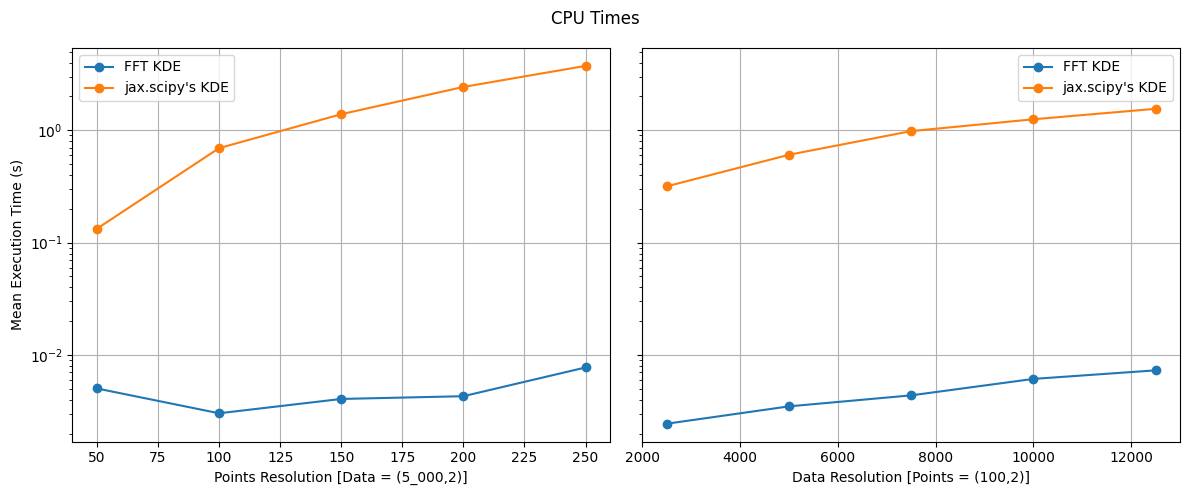

In [5]:
import matplotlib.pyplot as plt

labels = {'fft_kde': 'FFT KDE',
          'jax_kde':"jax.scipy's KDE"}

# Create a figure with two subplots side by side with shared y-axis
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

# First subplot - Points Resolution
for method in methods:
    ax1.plot(points_res, mean_time_point_res[method], marker='o', label=labels[method])
ax1.set_xlabel('Points Resolution [Data = (5_000,2)]')
ax1.set_ylabel('Mean Execution Time (s)')
ax1.set_yscale('log')
ax1.legend()
ax1.grid(True)

# Second subplot - Data Resolution
for method in methods:
    ax2.plot(data_res, mean_time_data_res[method], marker='o', label=labels[method])
ax2.set_xlabel('Data Resolution [Points = (100,2)]')
ax2.legend()
ax2.grid(True)

fig.suptitle('CPU Times')
plt.tight_layout()
plt.savefig(dir_parent+'../examples/cpu_bench_2d.png', dpi=600)
plt.show()

# 3D case

## 1. varying point resolution

In [6]:
from collections import defaultdict
import os,sys
from KDExpress import fft_kde3d, silverman_bw3d, build_hist_edges

key = jax.random.PRNGKey(42)
data_3d = generate_3d_data(key, n_samples=2500)
weights = (data_3d**2)[:,0]

dim =  50
bounds = [(data_3d[:,i].min()-0.5, data_3d[:,i].max()+0.5) for i in range(3)]
grids = [jnp.linspace(b[0], b[1], dim) for b in bounds]
points_x = grids[0]
points_y = grids[1]
points_z = grids[2]
px, py, pz = jnp.meshgrid(points_x, points_y, points_z, indexing='ij')
be = [build_hist_edges(points) for points in [points_x, points_y, points_z]]

fft_kde_3d_args = [points_x, points_y, points_z, data_3d]
fft_kde_3d_kwargs = {'weights': weights}

jax_kde_args = [points_x, points_y, points_z, data_3d]
jax_kde_kwargs = {'weights': weights, 'bw_method':silverman_bw3d(data_3d)[0]}

methods = {
  'fft_kde': (fft_kde3d, fft_kde_3d_args, fft_kde_3d_kwargs),
  'jax_kde': (jax_gkde_3d, jax_kde_args, jax_kde_kwargs)
}

def compute_benchmark_point_res(points_res):
  mean_times = defaultdict(list)
  for res in points_res:
    grids = [jnp.linspace(b[0], b[1], res) for b in bounds]
    points_x = grids[0]
    points_y = grids[1]
    points_z = grids[2]
    px, py, pz = jnp.meshgrid(points_x, points_y, points_z, indexing='ij')
    be = [build_hist_edges(points) for points in [points_x, points_y, points_z]]

    fft_kde_3d_args[0] = points_x
    fft_kde_3d_args[1] = points_y
    fft_kde_3d_args[2] = points_x

    jax_kde_args[0] = points_x
    jax_kde_args[1] = points_y
    jax_kde_args[2] = points_z


    print(f"\nResolution: {res} points")
    for method_name, (func, args, kwargs) in methods.items():
      mean, std = run_benchmark(func, args, kwargs)
      mean_times[method_name].append(float(mean))
      print(f"{method_name}: {mean:.5f} ± {std:.5f} s")
  return dict(mean_times)


points_res = [15, 30, 45, 60, 75]
mean_time_point_res = compute_benchmark_point_res(points_res)


Resolution: 15 points
fft_kde: 0.00219 ± 0.00062 s
jax_kde: 0.08762 ± 0.00466 s

Resolution: 30 points
fft_kde: 0.00311 ± 0.00091 s
jax_kde: 0.87832 ± 0.23505 s

Resolution: 45 points
fft_kde: 0.00623 ± 0.00229 s
jax_kde: 2.82141 ± 0.73440 s

Resolution: 60 points
fft_kde: 0.01171 ± 0.00468 s
jax_kde: 6.73591 ± 1.91225 s

Resolution: 75 points
fft_kde: 0.02128 ± 0.00846 s
jax_kde: 13.15720 ± 3.20680 s


## 2. varying data resolution

In [7]:
key = jax.random.PRNGKey(42)
data_3d = generate_3d_data(key, n_samples=2500)
weights = (data_3d**2)[:,0]

bounds = [(data_3d[:,i].min()-0.5, data_3d[:,i].max()+0.5) for i in range(3)]
grids = [jnp.linspace(b[0], b[1], 25) for b in bounds]
points_x = grids[0]
points_y = grids[1]
points_z = grids[2]
px, py, pz = jnp.meshgrid(points_x, points_y, points_z, indexing='ij')
be = [build_hist_edges(points) for points in [points_x, points_y, points_z]]

fft_kde_3d_args = [points_x, points_y, points_z, data_3d]
fft_kde_3d_kwargs = {'weights': weights}

jax_kde_args = [points_x, points_y, points_z, data_3d]
jax_kde_kwargs = {'weights': weights, 'bw_method':silverman_bw3d(data_3d)[0]}

methods = {
  'fft_kde': (fft_kde3d, fft_kde_3d_args, fft_kde_3d_kwargs),
  'jax_kde': (jax_gkde_3d, jax_kde_args, jax_kde_kwargs)
}

def compute_benchmark_point_res(data_res):
  mean_times = defaultdict(list)
  for res in data_res:
    key = jax.random.PRNGKey(42)
    data_3d = generate_3d_data(key, n_samples=res)
    weights = (data_3d**2)[:,0]
    bounds = [(data_3d[:,i].min()-0.5, data_3d[:,i].max()+0.5) for i in range(3)]
    grids = [jnp.linspace(b[0], b[1], 25) for b in bounds]
    points_x = grids[0]
    points_y = grids[1]
    points_z = grids[2]
    px, py, pz = jnp.meshgrid(points_x, points_y, points_z, indexing='ij')
    be = [build_hist_edges(points) for points in [points_x, points_y, points_z]]

    fft_kde_3d_args[0] = points_x
    fft_kde_3d_args[1] = points_y
    fft_kde_3d_args[2] = points_x
    fft_kde_3d_args[3] = data_3d

    jax_kde_args[0] = points_x
    jax_kde_args[1] = points_y
    jax_kde_args[2] = points_z
    jax_kde_args[3] = data_3d

    fft_kde_3d_kwargs['weights'] = weights
    jax_kde_kwargs['weights'] = weights

    print(f"\nResolution: {res} points")
    for method_name, (func, args, kwargs) in methods.items():
      mean, std = run_benchmark(func, args, kwargs)
      mean_times[method_name].append(float(mean))
      print(f"{method_name}: {mean:.5f} ± {std:.5f} s")
  return dict(mean_times)


data_res = [3000, 4000, 5000, 6000, 7000]
mean_time_data_res = compute_benchmark_point_res(data_res)


Resolution: 3000 points
fft_kde: 0.00291 ± 0.00073 s
jax_kde: 0.66679 ± 0.19195 s

Resolution: 4000 points
fft_kde: 0.00387 ± 0.00106 s
jax_kde: 0.78260 ± 0.21600 s

Resolution: 5000 points
fft_kde: 0.00523 ± 0.00133 s
jax_kde: 0.87764 ± 0.23554 s

Resolution: 6000 points
fft_kde: 0.00754 ± 0.00213 s
jax_kde: 1.11015 ± 0.40482 s

Resolution: 7000 points
fft_kde: 0.00898 ± 0.00320 s
jax_kde: 1.38912 ± 0.48874 s


## 3. 3d plots

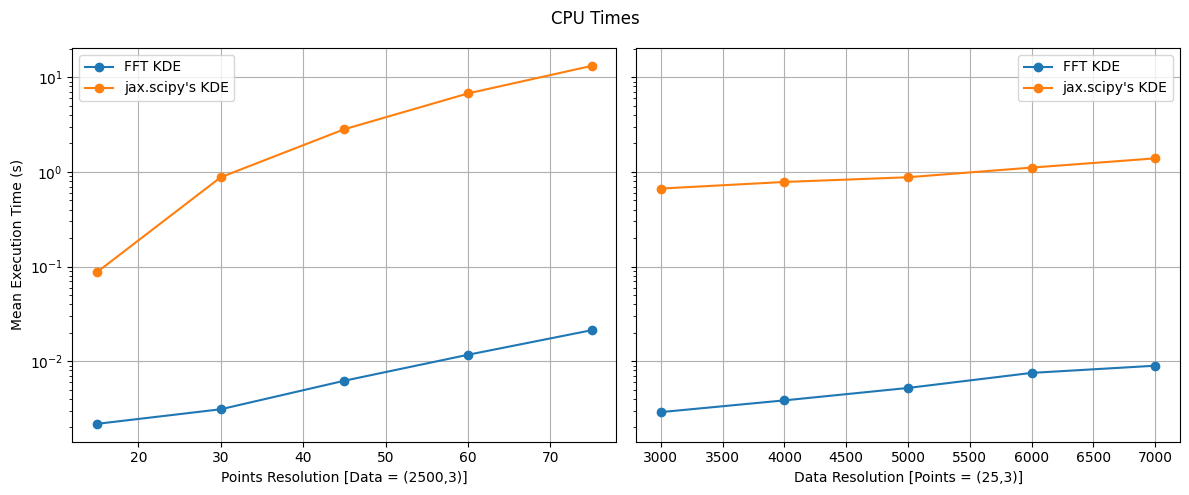

In [8]:
import matplotlib.pyplot as plt


labels = {'fft_kde': 'FFT KDE',
          'jax_kde':"jax.scipy's KDE"}

# Create a figure with two subplots side by side with shared y-axis
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

# First subplot - Points Resolution
for method in methods:
    ax1.plot(points_res, mean_time_point_res[method], marker='o', label=labels[method])
ax1.set_xlabel('Points Resolution [Data = (2500,3)]')
ax1.set_ylabel('Mean Execution Time (s)')
ax1.set_yscale('log')
ax1.legend()
ax1.grid(True)

# Second subplot - Data Resolution
for method in methods:
    ax2.plot(data_res, mean_time_data_res[method], marker='o', label=labels[method])
ax2.set_xlabel('Data Resolution [Points = (25,3)]')
ax2.legend()
ax2.grid(True)

fig.suptitle('CPU Times')
plt.tight_layout()
plt.savefig(dir_parent+'../examples/cpu_bench_3d.png', dpi=600)
plt.show()

In [ ]:
import time
import jax
jax.config.update("jax_enable_x64", True)
jax.config.update('jax_platform_name', 'cpu') # put 'gpu' here if you have one
import jax.numpy as jnp
from collections import defaultdict
from google.colab import drive
drive.mount('/content/gdrive', force_remount=True)
dir_parent    = "/content/gdrive/MyDrive/KDExpress/src/"
import sys
sys.path.append(dir_parent)
from KDExpress import histnd, build_hist_edges
import numpy as np


data = jnp.asarray(np.random.normal(size=(5000,2)))
w = jnp.asarray(np.random.uniform(0,1,size=(5000,)))

bounds = [(data[:,i].min()-0.5, data[:,i].max()+0.5) for i in range(data.shape[1])]
grids = [jnp.linspace(b[0], b[1], 50) for b in bounds]
points_x = grids[0]
points_y = grids[1]
#points_z = grids[2]
px, py = jnp.meshgrid(points_x, points_y, indexing='ij')
be = [build_hist_edges(points) for points in [points_x, points_y]]
print('here')
a, b = histnd(data, be, weights=w, density=True)
print(a)
%timeit histnd(data, be, weights=w, density=True)

Mounted at /content/gdrive
here
[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


In [ ]:
aa, bb = jnp.histogramdd(data, be, weights=w, density=True)
%timeit jnp.histogramdd(data, be, weights=w, density=True)